Defunct script, originally where all analyses were done. The different sections of this notebook are succeeded by invidual jupyter notebooks in the same directory except for graphing topic uniqueness and topic bar charts, which were both not included in the paper.

Graph Topic Proportions per epoch, Clustering Heatmaps, and Get top words per topic + Enrichments are all succeeded in their respective individual notebooks.

In [1]:
import sys
sys.path.append('WTM')

import pickle as p
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import new_ds
from new_ds import mm_Dataset
from WTM_model import WTM
from utils import calc_topic_uniqueness
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
pd.set_option('display.max_rows', None)
import pickle

import seaborn as sns
import time

In [10]:
def my_softmax(df):
    
    maxes = df.max(axis=1)
    diffs = df.sub(maxes, axis=0)
    num = np.exp(diffs)
    denom = num.sum(axis=1)
    out = num.div(denom, axis=0)
    return out

def load_model(model_prefix, docSet):
    checkpoint = torch.load(f'WTM_checkpoints/{model_prefix}')
    param = checkpoint["param"]
    model = WTM(**param)
    model.load_model(checkpoint["net"])
    model.id2token = {v: k for k,v in docSet.dictionary.token2id.items()}
    return model

def get_embeds(model, docSet, labels_fname = None):
    embeds = model.get_embed(train_data=docSet, num=1000)

    if labels_fname:
        with open(labels_fname, 'r') as file:
            labels_list = [line.strip() for line in file.readlines()]
        out_df = pd.DataFrame(embeds, index=labels_list)
        return out_df
        
    return pd.DataFrame(embeds)

def calculate_phis(docSet, model):
    out_dict = {}
    all_phi_raw = model.get_topic_word_dist(normalize=False)
    headers = np.concatenate([expmat.columns for expmat in docSet.expmats.values()])
    all_phi_raw = pd.DataFrame(all_phi_raw, columns = headers)
    for data_type in np.unique(docSet.label_type):
        type_raw = all_phi_raw.iloc[:, docSet.label_type==data_type]
        out_dict[data_type] = my_softmax(type_raw)
    return out_dict

In [11]:
ckpts_covid_t10_a5e2 = [f'covid_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]# best one!
ckpts_crc_t10_a5e2 = [f'crc_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibd_t10_a5e2 = [f'ibd_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibs_t10_a5e2 = [f'ibs_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]

ckpts_crc_log = [f'crc_tp10_a0.05_lr0.0005_log_nonorm/epoch_{i*25}.ckpt' for i in range(1, 21)]
ckpts_ibd_log = [f'ibd_tp10_a0.05_lr0.0005_log_nonorm/epoch_{i*25}.ckpt' for i in range(1, 21)]
ckpts_ibs_log = [f'ibs_tp10_a0.05_lr0.0005_log_nonorm/epoch_{i*25}.ckpt' for i in range(1, 21)]

ckpts_crc = [f'crc_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibd = [f'ibd_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibs = [f'ibs_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]

In [12]:
#load expression data
covid_docSet = mm_Dataset(rebuild=True,
                        data_dir='/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/covid_data',
                        mode_names=['gene', 'microbeR', 'premiR'],
                        expmat_fnames=['covid_gene.csv', 'covid_microbeR.csv', 'covid_premiR.csv'],
                        metadata_fname='covid_metadata.csv',
                        out_fname='covid_docDataset.pkl',
                        scale='gene'
                       )

crc_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/crc_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['crc_gene.csv', 'crc_microbeR.csv'],
                        metadata_fname = 'crc_metadata.csv',
                        out_fname = 'crc_docDataset.pkl'
                       )

ibd_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/ibd_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibd_gene.csv', 'ibd_microbeR.csv'],
                        metadata_fname = 'ibd_metadata.csv',
                        out_fname = 'ibd_docDataset.pkl')

ibs_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/ibs_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibs_gene.csv', 'ibs_microbeR.csv'],
                        metadata_fname = 'ibs_metadata.csv',
                        out_fname = 'ibs_docDataset.pkl')

Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding


### Clustering Heatmaps

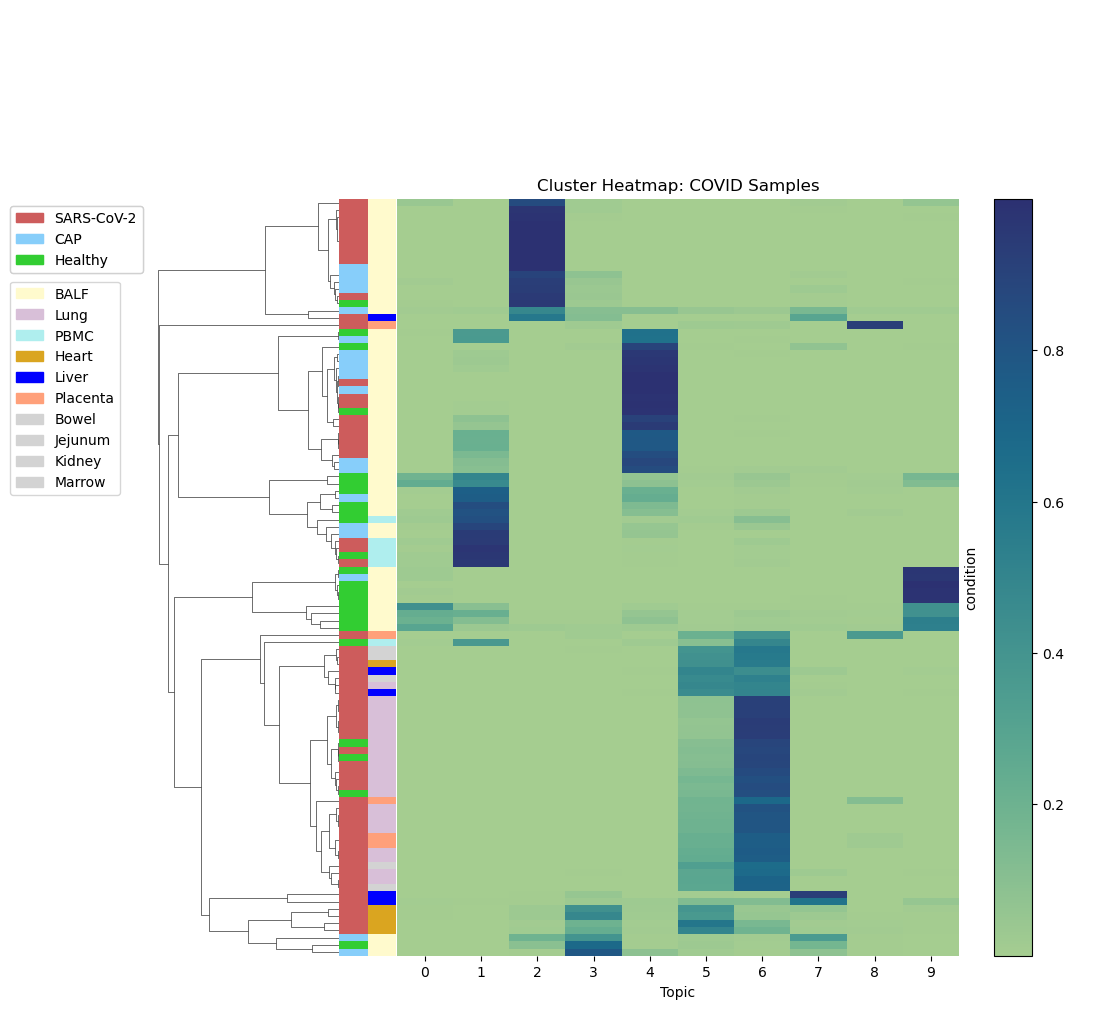

In [14]:
curr_model = load_model(ckpts_covid_t10_a5e2[-1], covid_docSet)
embeds_df = get_embeds(curr_model, covid_docSet) # fuck i still need self.docs to get embeds, maybe try to redo this?
embeds_df.index = covid_docSet.samp_metadata['condition']

#Create additional row_colors here
samp_cmap = {'BALF': 'lemonchiffon', 'Lung': 'thistle', 'PBMC': 'paleturquoise', 'Heart':'goldenrod',
             'Liver':'blue', 'Placenta':'lightsalmon', 'Bowel':'lightgrey', 'Jejunum':'lightgrey', 'Kidney':'lightgrey',
             'Marrow':'lightgrey'}
rc_samp = covid_docSet.samp_metadata['tissue'].map(samp_cmap)

cond_cmap = {'SARS-CoV-2': 'indianred', 'CAP':'lightskyblue', 'Healthy':'limegreen'}
rc_cond = covid_docSet.samp_metadata['condition'].map(cond_cmap)

samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Cluster Heatmap: COVID Samples')
plt.show()

#### Getting Heatmap for CRC Data

In [106]:
crc_docSet.samp_metadata['tissue'].value_counts()

tissue
Right_colon           30
Rectosigmoid_colon    12
Transverse_colon      12
Sigmoid_colon         10
Cecum                 10
Rectum                 6
Descending_colon       4
Ileum                  2
Colon                  2
Name: count, dtype: int64

In [19]:
model = load_model(ckpts_crc[-1], crc_docSet)
embeds_df = get_embeds(model, crc_docSet)
embeds_df.index = crc_docSet.samp_metadata['condition']

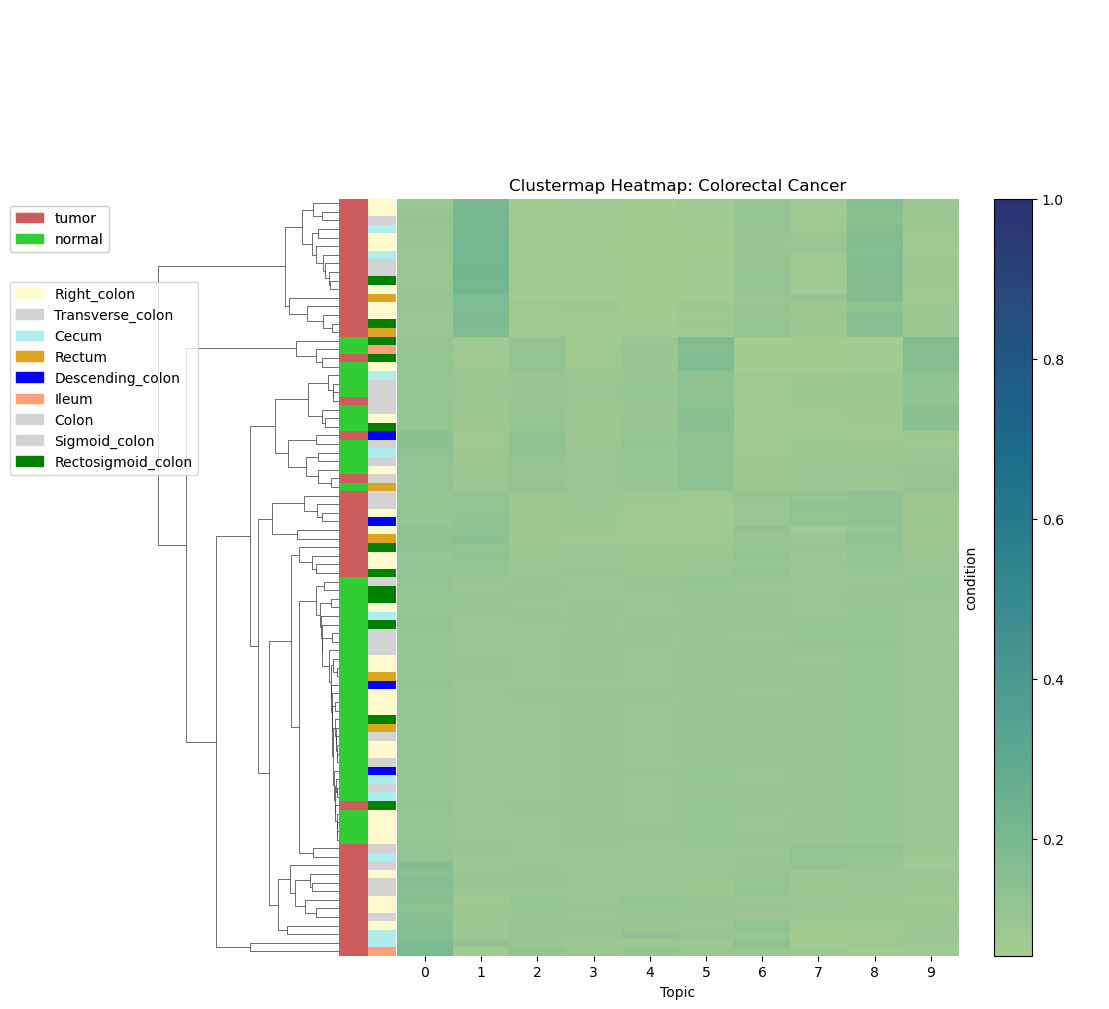

In [22]:
# crc_docSet.samp_metadata['tissue'].value_counts()
# conditions: tumor, normal
# tissues: Right_colon, Rectosigmoid_colon, Transverse_colon, Sigmoid_colon, Cecum, Rectum, Descending_colon, Ileum, Colon

samp_cmap = {'Right_colon': 'lemonchiffon', 'Transverse_colon': 'lightgrey',
             'Cecum': 'paleturquoise', 'Rectum':'goldenrod',
             'Descending_colon':'blue', 'Ileum':'lightsalmon',
             'Colon':'lightgrey', 'Sigmoid_colon': 'lightgrey',
             'Rectosigmoid_colon':'green'}
rc_samp = crc_docSet.samp_metadata['tissue'].map(samp_cmap)

cond_cmap = {'tumor': 'indianred', 'normal':'limegreen'}
rc_cond = crc_docSet.samp_metadata['condition'].map(cond_cmap)

samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None, vmax=1)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap: Colorectal Cancer')
plt.show()

In [22]:
model = ckpts_crc_log[-1]
embeds_df = get_embeds(model, crc_logSet)
embeds_df.index = crc_logSet.samp_metadata['condition']

/home/rtl35/.conda/envs/NTM/lib/python3.11/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)


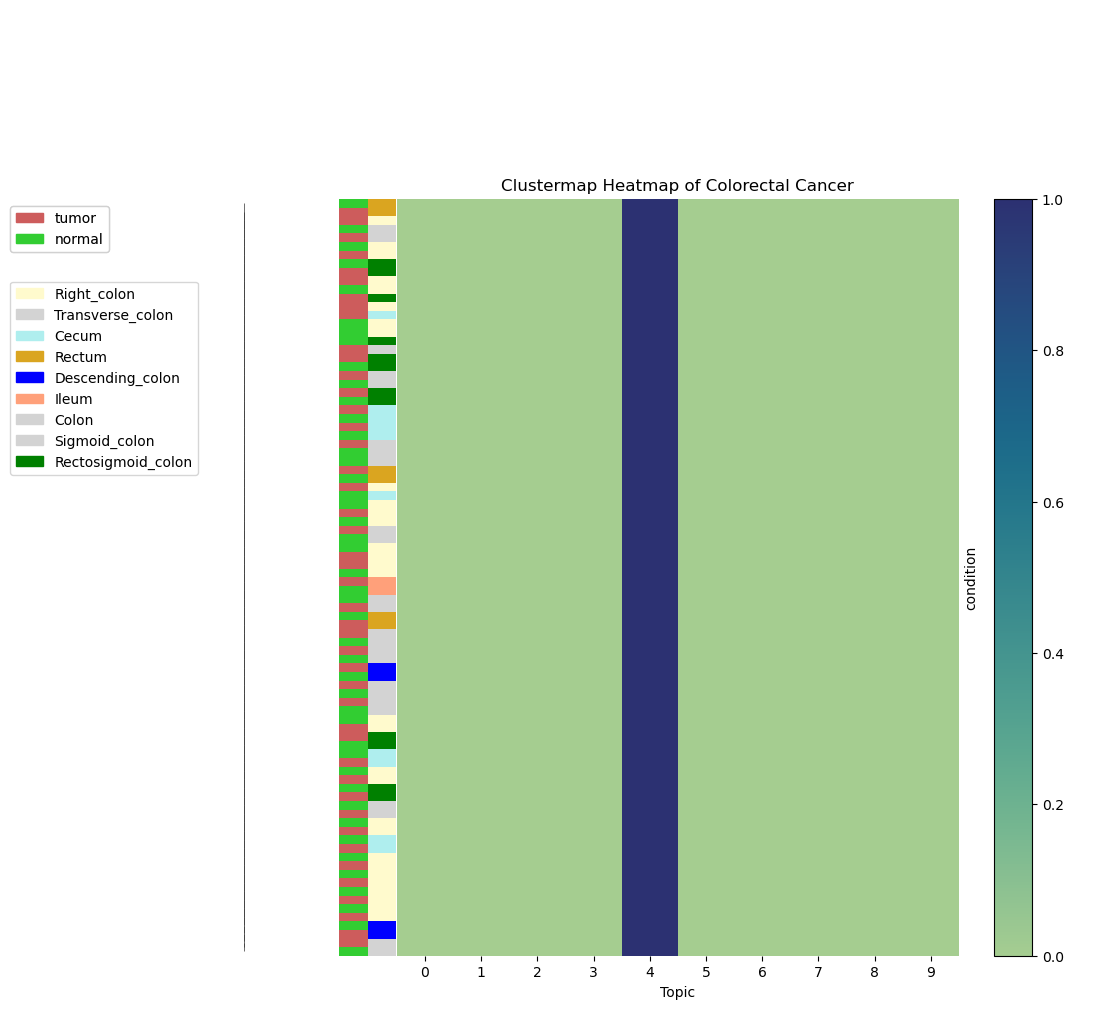

In [23]:
samp_cmap = {'Right_colon': 'lemonchiffon', 'Transverse_colon': 'lightgrey',
             'Cecum': 'paleturquoise', 'Rectum':'goldenrod',
             'Descending_colon':'blue', 'Ileum':'lightsalmon',
             'Colon':'lightgrey', 'Sigmoid_colon': 'lightgrey',
             'Rectosigmoid_colon':'green'}
rc_samp = crc_logSet.samp_metadata['tissue'].map(samp_cmap)

cond_cmap = {'tumor': 'indianred', 'normal':'limegreen'}
rc_cond = crc_logSet.samp_metadata['condition'].map(cond_cmap)

samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap of Colorectal Cancer')
plt.show()

#### Getting heatmap for IBD Data

In [25]:
ibd_docSet.samp_metadata['condition'].value_counts()

condition
CD        34
UC        22
nonIBD    22
Name: count, dtype: int64

In [23]:
model = load_model(ckpts_ibd_t10_a5e2[-1], ibd_docSet)
embeds_df = get_embeds(model, ibd_docSet)
embeds_df.index = ibd_docSet.samp_metadata['condition']

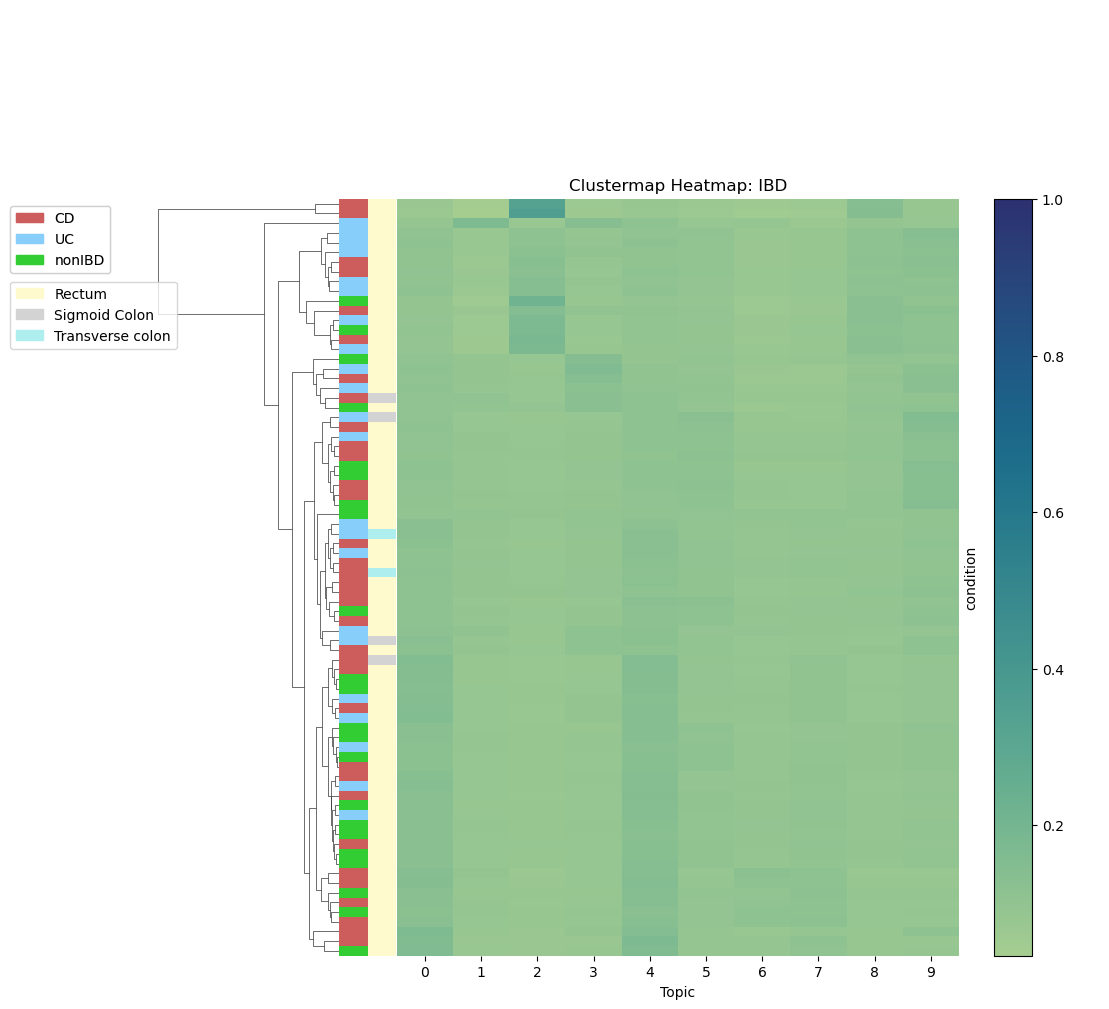

In [24]:
cond_cmap = {'CD': 'indianred', 'UC':'lightskyblue', 'nonIBD':'limegreen'}
rc_cond = ibd_docSet.samp_metadata['condition'].map(cond_cmap)

samp_cmap = {'Rectum': 'lemonchiffon', 'Sigmoid Colon': 'lightgrey',
             'Transverse colon': 'paleturquoise'}
rc_samp = ibd_docSet.samp_metadata['tissue'].map(samp_cmap)


samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None, vmax=1)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap: IBD')
plt.show()

In [25]:
embeds_df = get_embeds(ckpts_ibd_log[-1], ibd_logSet)
embeds_df.index = ibd_logSet.samp_metadata['condition']

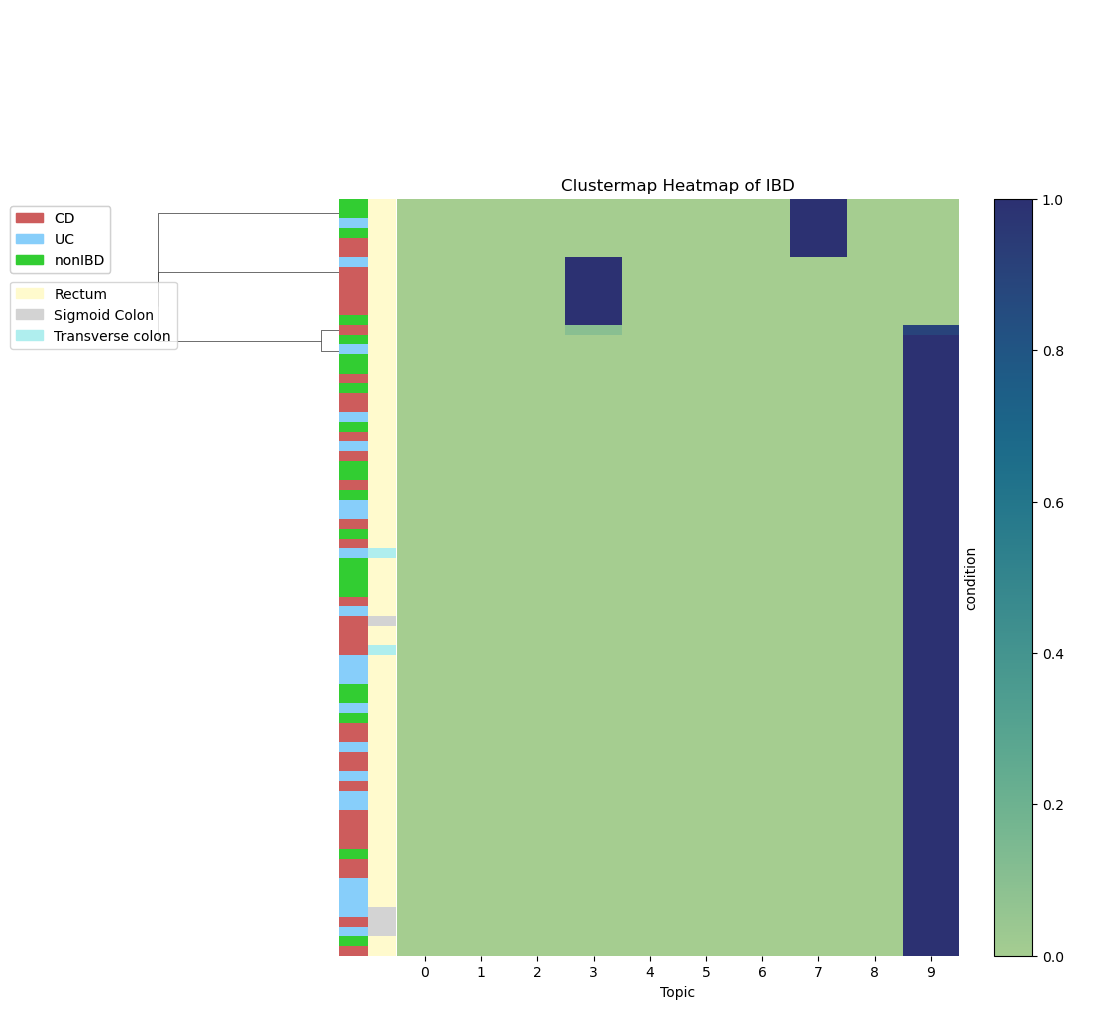

In [26]:
cond_cmap = {'CD': 'indianred', 'UC':'lightskyblue', 'nonIBD':'limegreen'}
rc_cond = ibd_logSet.samp_metadata['condition'].map(cond_cmap)

samp_cmap = {'Rectum': 'lemonchiffon', 'Sigmoid Colon': 'lightgrey',
             'Transverse colon': 'paleturquoise'}
rc_samp = ibd_logSet.samp_metadata['tissue'].map(samp_cmap)


samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap of IBD')
plt.show()

#### Getting Heatmap for IBS Data

In [29]:
model = load_model(ckpts_ibs_t10_a5e2[-1], ibs_docSet)
embeds_df = get_embeds(model, ibs_docSet)
embeds_df.index = ibs_docSet.samp_metadata['condition']
ibs_docSet.samp_metadata['tissue'] = None

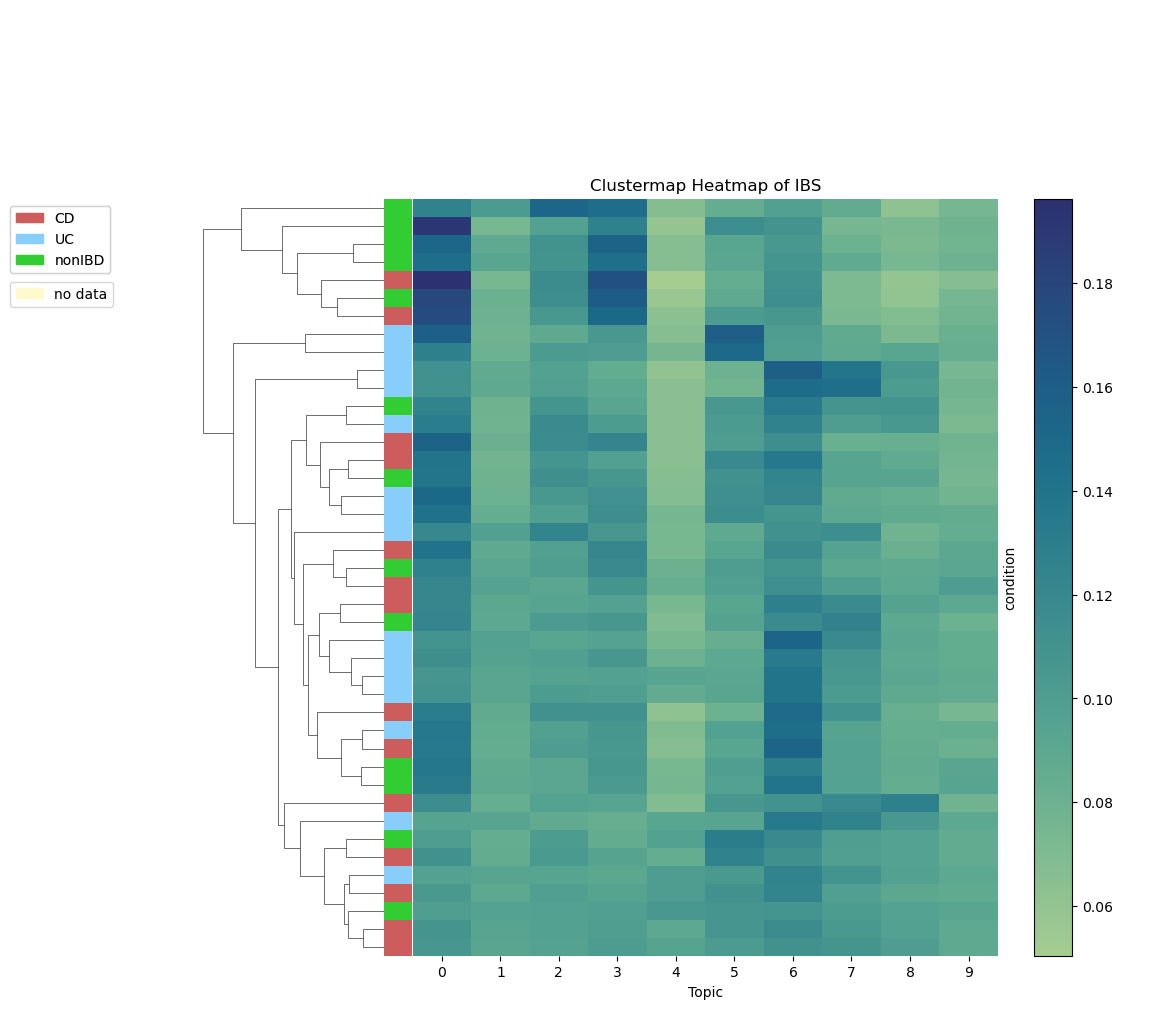

In [30]:
cond_cmap = {'IBS-D': 'indianred', 'IBS-C':'lightskyblue', 'Healthy':'limegreen'}
rc_cond = ibs_docSet.samp_metadata['condition'].map(cond_cmap)

samp_cmap = {'no data': 'lemonchiffon'}
# rc_samp = ibs_docSet.samp_metadata['tissue'].map(samp_cmap)


samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
# cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap of IBS')
plt.show()

In [81]:
model = load_model(ckpts_ibs_log[-1])
embeds_df = get_embeds(model, ibs_logSet)
embeds_df.index = ibs_logSet.samp_metadata['condition']
ibs_docSet.samp_metadata['tissue'] = None

/home/rtl35/.conda/envs/NTM/lib/python3.11/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)


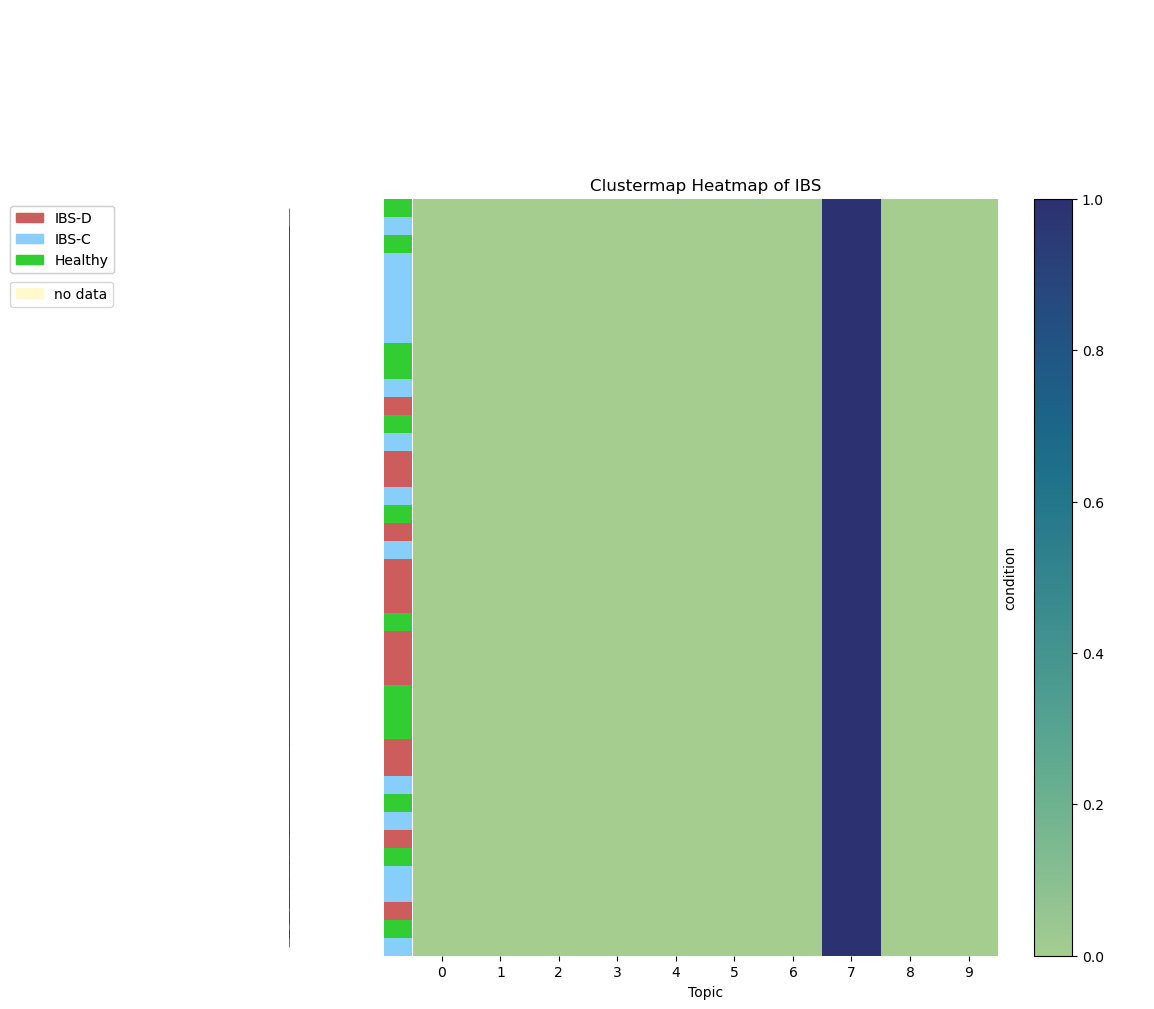

In [82]:
cond_cmap = {'IBS-D': 'indianred', 'IBS-C':'lightskyblue', 'Healthy':'limegreen'}
rc_cond = ibs_docSet.samp_metadata['condition'].map(cond_cmap)

samp_cmap = {'no data': 'lemonchiffon'}
# rc_samp = ibs_docSet.samp_metadata['tissue'].map(samp_cmap)


samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
# cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap of IBS')
plt.show()

### Get top words per topic

In [93]:
curr_model = load_model(ckpts_crc[-1], crc_docSet)
curr_phis = calculate_phis(crc_docSet, curr_model)

In [111]:
top_20s = curr_phis['gene'].iloc[1, :].sort_values(ascending=False).iloc[:20]
top_20s
pd.DataFrame(
    {'Name': [crc_docSet.dictionary[i] for i in top_20s.index.values],
    'Topic Proportion (phi)': top_20s.values}
)

,Name,Topic Proportion (phi)
0,EEF1A1,0.008008
1,MTRNR2L1,0.005147
2,PIGR,0.004912
3,MUC2,0.003198
4,FAT1,0.002941
5,CEACAM5,0.002830
6,FCGBP,0.002780
7,AHNAK,0.002767
8,ACTB,0.002172
9,SLC12A2,0.002158


In [112]:
top_20_is = top_20s.index.values
for idx in top_20_is:
    print(crc_docSet.dictionary[idx])

EEF1A1
MTRNR2L1
PIGR
MUC2
FAT1
CEACAM5
FCGBP
AHNAK
ACTB
SLC12A2
PABPC1
ACTG1
EEF2
RPLP0
OLFM4
HSPA8
COL3A1
SPTBN1
CD24
KRT8


In [ ]:
# COVID Topic 6 WikiPathway Enrichments
categories = ['miRNA Targets In ECM And Membrane Receptors WP2911',
              'Focal Adhesion PI3K Akt mTOR Signaling Pathway WP3932',
              'PI3K Akt Signaling Pathway WP4172',
              'Inflammatory Response Pathway WP453',
              'VEGFA VEGFR2 Signaling WP3888',
              'miR 509 3P Alteration Of YAP1 ECM',
              'TGF Beta Signaling Pathway WP366',
              '	NRF2 Pathway WP2884',
              'Focal Adhesion WP306',
              'IL 24 Signaling Pathway WP5413'][::-1]
values = [5.256e-9, 3.658e-7, 7.073e-7, 0.000003412, 0.00005329, 0.0001280, 0.0002951, 0.0003581, 0.0009763, 0.001518][::-1]

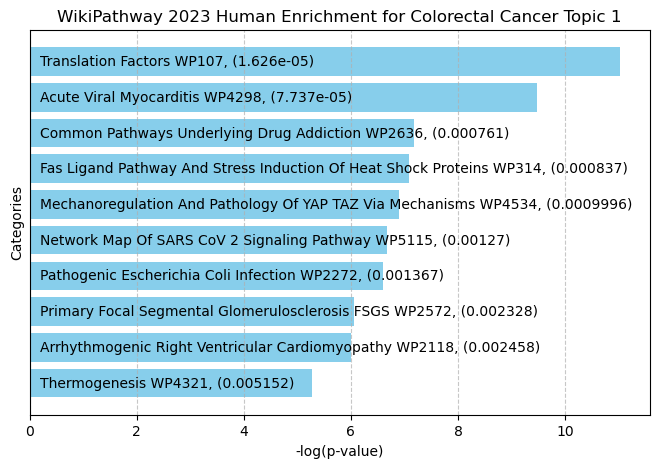

In [115]:
categories = ['Translation Factors WP107',
              'Acute Viral Myocarditis WP4298',
              'Common Pathways Underlying Drug Addiction WP2636',
              'Fas Ligand Pathway And Stress Induction Of Heat Shock Proteins WP314',
              'Mechanoregulation And Pathology Of YAP TAZ Via Mechanisms WP4534',
              'Network Map Of SARS CoV 2 Signaling Pathway WP5115',
              'Pathogenic Escherichia Coli Infection WP2272',
              'Primary Focal Segmental Glomerulosclerosis FSGS WP2572',
              'Arrhythmogenic Right Ventricular Cardiomyopathy WP2118',
              'Thermogenesis WP4321'][::-1]

values = [0.00001626, 0.00007737, 0.0007610, 0.0008370, 0.0009996, 0.001270, 0.001367, 0.002328, 0.002458, 0.005152][::-1]

plt_vals = [-np.log(val) for val in values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(categories, plt_vals , color='skyblue', )

# Add text labels on bars
for cat, bar, raw_val in zip(categories, bars, values):
    
    plt.text(0.2, bar.get_y() + bar.get_height()/2, 
             f'{cat}, ({raw_val})',
             va='center', ha='left', fontsize=10, color='black')

# Adding title and labels
plt.yticks([])
plt.xlabel('-log(p-value)')
plt.ylabel('Categories')
plt.title('WikiPathway 2023 Human Enrichment for Colorectal Cancer Topic 1')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# COVID Topic 6 KEGG 2021 Enrichments
categories = ['Antigen processing and presentation',
              'Lipid and atherosclerosis',
              'Estrogen signaling pathway',
              'Protein processing in endoplasmic reticulum	',
              'PI3K-Akt signaling pathway',
              'Salmonella infection',
              'Fluid shear stress and atherosclerosis',
              'Legionellosis',
              'Focal adhesion',
              'ECM-receptor interaction'][::-1]
values = [1.173e-8	, 4.919e-8, 2.000e-7, 6.021e-7, 9.264e-7, 0.000003823, 0.000009928, 0.00002417, 0.00004228,0.00008888][::-1]

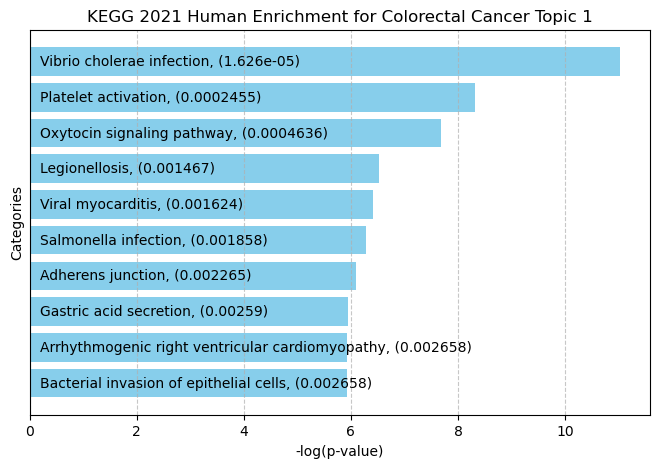

In [117]:
categories = ['Vibrio cholerae infection',
             'Platelet activation',
             'Oxytocin signaling pathway',
             'Legionellosis',
             'Viral myocarditis',
             'Salmonella infection',
             'Adherens junction',
             'Gastric acid secretion',
             'Arrhythmogenic right ventricular cardiomyopathy',
             'Bacterial invasion of epithelial cells'][::-1]

values = [0.00001626, 0.0002455, 0.0004636, 0.001467, 0.001624, 0.001858, 0.002265, 0.002590, 0.002658, 0.002658][::-1]

plt_vals = [-np.log(val) for val in values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(categories, plt_vals , color='skyblue', )

# Add text labels on bars
for cat, bar, raw_val in zip(categories, bars, values):
    
    plt.text(0.2, bar.get_y() + bar.get_height()/2, 
             f'{cat}, ({raw_val})',
             va='center', ha='left', fontsize=10, color='black')

# Adding title and labels
plt.yticks([])
plt.xlabel('-log(p-value)')
plt.ylabel('Categories')
plt.title('KEGG 2021 Human Enrichment for Colorectal Cancer Topic 1')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()